# Setup 
(Run these first)

In [21]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using AttitudeBehaviorDynamicsModel
using LinearAlgebra, Statistics, Distributions
using DelimitedFiles, FileIO, JLD2
using SharedArrays, Graphs
using Colors, GraphPlot
using GaussianMixtures
using CairoMakie

  Activating project at `/scratch/gpfs/CTARNITA/kfinke/SABC/AgentBasedModel`


## Plotting functions

In [23]:
function blank_axis(; 
    xcolor     = :blue,
    ycolor     = :black,
    xlabel     = "",
    ylabel     = "",
    xticks     = nothing,
    yticks     = nothing,
    xaxiswidth = 2,
    yaxiswidth = 2,
    xtickwidth = 2,
    ytickwidth = 2,
    xlabelsize=20,
    ylabelsize=20,
    size       = (500, 500),
    title      =  "",
    padding    = 12
)

    fig = Figure(size = size,figure_padding = (padding, padding, padding, padding))

    ax = Axis(fig[1, 1]; 
        xlabel = xlabel,
        ylabel = ylabel,
        title = title,

        # Tick and label colors
        xticklabelcolor = xcolor,
        yticklabelcolor = ycolor,
        xtickcolor = xcolor,
        ytickcolor = ycolor,
        xlabelcolor = xcolor,
        ylabelcolor = ycolor,

        #label sizes
        xlabelsize=xlabelsize,
        ylabelsize=ylabelsize,

        # Tick widths
        xtickwidth = xtickwidth,
        ytickwidth = ytickwidth,
        xticksize = 8,
        yticksize = 8,

        # Grid off
        xgridvisible = false,
        ygridvisible = false,

        # Spine colors and widths
        bottomspinecolor = xcolor,
        leftspinecolor = ycolor,
        spinewidth = yaxiswidth,

        # Optional: hide top and right spines
        topspinevisible = false,
        rightspinevisible = false,
    )

    if xticks !== nothing
        ax.xticks = xticks
    end
    if yticks !== nothing
        ax.yticks = yticks
    end

    return fig, ax
end

#Define colors
betaBlue = "#4a86e8"
alphaRed = "#ff6370"
lambdaPurple = "#984ea3"
negOnly = "#f7bb7cff"  
negOnlyFaint="#f7bb7c55"
posOnly = "#9fcb8cff"
posOnlyFaint = "#9fcb8c55" 
sponBoth = "#bddaff6d"
inducible = "#ffebb0ff"
inducibleFaint = "#ffebb055"
nodata="#00000000"
sponNeg = "#c8e1bcff"
sponPos = "#fad7b3ff"
sponNegFaint = "#c8e1bc55"
sponPosFaint = "#fad7b355"

movingaverage(g, n) = [i < n ? mean(g[begin:i]) : mean(g[i-n+1:i]) for i in 1:length(g)];

## Set Parameters Here

In [24]:
# Behavior Incentives, -1 to 1
β = 0.0

# Attitude Biases, -1 to 1
α = 0.0

# Attitude-Behavior Linkage strength, 0 to 1
λ = 0.0

# Population Size
N = 100

# Behavior Memory Length (for calculating H)
M = 20

# error rate
err = 0.01

# simulation timelimit
timelimit = 50000

# social network type
networkType = "wellmixed"

# type of tracker to save simulation outputs (visual recommended to reproduce plots of the paper)
trackerType ="visual" 

# Attitude update and Behavior update rates
rates = [0.1,0.1]

# the folder where the simulations will be saved
simulationName="freestyle"

#how many repetitions of each simulation do you want
repsEach=1

#title for your plot and saved plot image
titleString="my simulations"

# you probably don't want to change these unless you're making your own versions of the model (if so, cool!)
attProbsType="model13Version"     # How to calculate attitude update probabilities 
behavProbsType="model13Version"   # How to calculate behavior update probabilities 
λBAdirectionType="lastBehavior"   # how to calculate the direction of λ (see supplemental material for notes on this)
socialInfluenceType="mean"        # how to calculate S
historyDependenceType="mean"      # how to calculate H
;

# Run your simulation + plot

file doesn't exist, creating
Starting simulation alpha=0.0, beta=0.0, rates=[0.1, 0.1], λ=0.0 M=20 ....
  2.881193 seconds (36.71 M allocations: 1.991 GiB, 30.92% gc time)
Starting simulation alpha=0.0, beta=0.0, rates=[0.1, 0.1], λ=0.0 M=20 ....
  2.955914 seconds (36.77 M allocations: 1.994 GiB, 30.21% gc time)
Starting simulation alpha=0.0, beta=0.0, rates=[0.1, 0.1], λ=0.0 M=20 ....
  2.937347 seconds (36.80 M allocations: 1.995 GiB, 28.03% gc time)
Starting simulation alpha=0.0, beta=0.0, rates=[0.1, 0.1], λ=0.0 M=20 ....
  3.227027 seconds (36.78 M allocations: 1.995 GiB, 27.87% gc time)
Starting simulation alpha=0.0, beta=0.0, rates=[0.1, 0.1], λ=0.0 M=20 ....
  3.112250 seconds (36.70 M allocations: 1.992 GiB, 27.39% gc time)
Starting simulation alpha=0.0, beta=0.0, rates=[0.1, 0.1], λ=0.0 M=20 ....
  3.060463 seconds (36.81 M allocations: 1.997 GiB, 27.02% gc time)


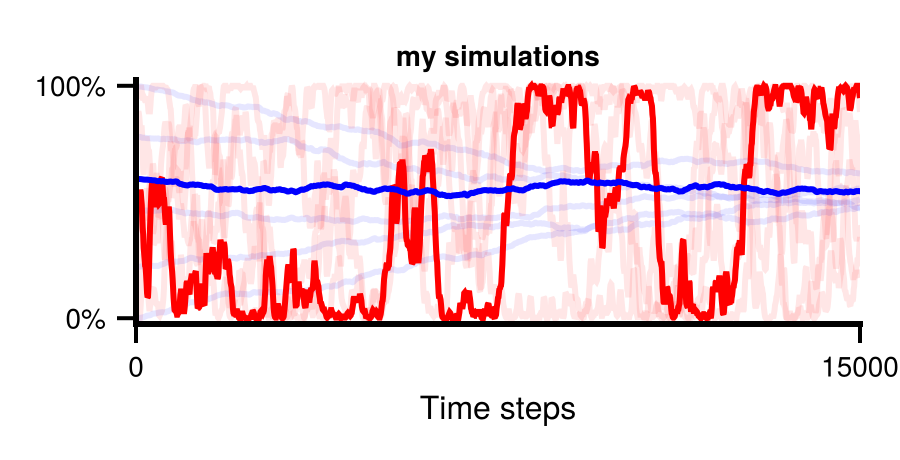

In [25]:
#Plotting Parameters
plotRed = true
plotBlue= true
startTime=1
plotTL = 15000      # plot time limit
lw=3              # line width
highlight = 3     # which of the simulations to plot in bold color (in order to visually highlight a single trajectory)

#----------------------------------------------------------------------------------------------------------------------

# Load File
paramStr = getParamString(N,M,rates,λ,λ,β,α,err,networkType,trackerType,attProbsType,λBAdirectionType,socialInfluenceType,behavProbsType,historyDependenceType,timelimit)
getPath = "../simulations/$simulationName/$paramStr"
jld_path = getPath*"/all_reps.jld2"

attitudes=ones(N) .*-1
behaviors=ones(N,M) .*-1

if isfile(jld_path)
    f = jldopen(jld_path, "r")
    has_rep = haskey(f, "pop_5")
    close(f)
else
    has_rep = false
end


if !has_rep
    println("file doesn't exist, creating")


    for (rr, startingLoc) in enumerate(range(0,1,step=0.2))

        newAtts = copy(attitudes)
        newBehavs = copy(behaviors)
        newAtts[rand(N) .< 1-startingLoc] .*= -1
        newBehavs[rand(N) .< 1-startingLoc,:] .*= -1

        startingPop=generatePop(N,M,rates,λ,λ,β,α,err,networkType,attProbsType,λBAdirectionType,socialInfluenceType,behavProbsType,historyDependenceType,lowercase(trackerType),attitudes=newAtts,behaviors=newBehavs)

        reps = repsEach*rr

        println("Starting simulation alpha=$α, beta=$β, rates=$rates, λ=$λ M=$M ....")
        @time simulate(reps,N,M,rates,λ,λ,β,α,err,timelimit,simulationName,startingPop=startingPop,attProbsType=attProbsType,λBAdirectionType=λBAdirectionType,socialInfluenceType=socialInfluenceType,behavProbsType=behavProbsType,historyDependenceType=historyDependenceType,trackFreq=Int(ceil(timelimit/5000)),trackerType=trackerType,networkType=networkType,untilFixation=false,savePop=true)
    end

end

ylabel = "Frequency of "

if plotRed
    ylabel = ylabel * "A+"
end
if plotBlue && plotRed
    ylabel = ylabel * " & "
end
if plotBlue
    ylabel = ylabel * "B+"
end


#set up blank plot
fig, ax = blank_axis(
    xcolor = :black,
    ycolor = :black,
    xlabel = "Time steps",
    #ylabel = ylabel,
    xticks = ([1,plotTL], ["0", "$plotTL"]),
    yticks = ([-1,1], ["0%", "100%"]),
    xaxiswidth = 3,
    yaxiswidth = 3,
    size = (450,230),#(200, 170)
    title=titleString,
    padding = 20,
    ylabelsize=16,
    xlabelsize=16
)

limits!(ax, startTime, plotTL, -1.05, 1.05)

# Plot each repetition in faded color
for rr in 1:repsEach*6#[1,2,3,4,5,6]
    
    f = jldopen(jld_path, "r")
    pop = f["pop_$rr"]
    close(f)

    if plotRed
        lines!(ax, pop.tracker.times, movingaverage(pop.tracker.attMean, 4); color = (:red, 0.1), linewidth = 3)
    end
    if plotBlue
        lines!(ax, pop.tracker.times, movingaverage(pop.tracker.behavMean, 4); color = (:blue, 0.1), linewidth = 3)
    end
end

# Highlighted repetition
rr = highlight

f = jldopen(jld_path, "r")
pop = f["pop_$rr"]
close(f)

if plotRed
    lines!(ax, pop.tracker.times, movingaverage(pop.tracker.attMean, 4); color = :red, linewidth = 3)
end
if plotBlue
    lines!(ax, pop.tracker.times, movingaverage(pop.tracker.behavMean, 4); color = :blue, linewidth = 3)
end
save("../plots/timeseries $(titleString).png", fig)
fig